# CANCER REG

Hemos de responder a las siguientes preguntas:

1. ¿Qué variables parecen tener un mayor impacto sobre la tasa de mortalidad del análisis estadístico?, ¿Cómo podemos validarlo?
2. Dentro del modelo de regresión lineal, ¿Qué variables son las que más impacto tienen sobre el modelo?, ¿Cómo de significativas son con respecto al modelo?
3. ¿Cómo se distribuyen los residuos de la regresión?, ¿Qué información se puede extraer de los mismos?

Primero vamos a cargar la data  y realizar un analisis exploratorio de la misma. Para esto, vamos a cargar las librerías necesarias y la data.


## Import librerías and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)

# Load Data
data = pd.read_csv('./data/cancer_reg.csv')

print("The shape of data: ", data.shape)

The shape of data:  (3047, 33)


Bien podemos ver que son muchas variables, vamos a explorar cada una de ellas para saber de que se tratan y así tener una idea de que data tenemos entre manos y que variables pueden ser relevantes para nuestro análisis. Para esto, vamos a utilizar la función `info()` de pandas para obtener información sobre las columnas y sus tipos de datos, y la función `describe()` para obtener estadísticas descriptivas de las variables numéricas.

In [2]:
# Print INFO
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   object 
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  geography                3047 non-null   object 
 13  percentmarried           3047 non-null   float64
 14  pctnohs18_24            

1. **Estadísticas de Cáncer (Variables de Salud)**

`avganncount`: Media de casos de cáncer reportados anualmente en el condado.

`avgdeathsperyear`: Media de muertes anuales atribuidas al cáncer.

`target_deathrate` (Variable Objetivo): Tasa de mortalidad por cáncer por cada 100.000 habitantes. Es el "indicador estrella" que queremos explicar o predecir.

`incidencerate`: Tasa de nuevos diagnósticos por cada 100.000 habitantes.

1. **Factores Socioeconómicos**

`medincome`: Ingreso mediano por hogar. Es la "cartera" promedio de la zona.

`povertypercent`: Porcentaje de la población viviendo bajo el umbral de pobreza.

`binnedinc`: El ingreso mediano clasificado en intervalos (bins). Útil para análisis categóricos.

`studypercap`: Número de estudios clínicos per cápita realizados en la zona.

1. **Demografía**

`popest2015`: Estimación de la población total en el año 2015.

`geography`: Nombre del condado y el estado.

`medianage` / `medianagemale` / `medianagefemale`: Edad mediana total, de hombres y de mujeres.

`birthrate`: Tasa de natalidad.

`percentmarried` / `pctmarriedhouseholds`: Porcentaje de personas casadas y hogares compuestos por parejas casadas.

1. **Educación y Empleo**

`pctnohs18_24` / `pcths18_24` / `pctsomecol18_24` / `pctbachdeg18_24`: Nivel educativo alcanzado por jóvenes de 18 a 24 años (Sin secundaria, secundaria, algo de universidad o título universitario).

`pcths25_over` / `pctbachdeg25_over`: Nivel de estudios (Secundaria o Grado) para mayores de 25 años. Es como medir cuántos "libros" se han leído en el barrio a largo plazo.

`pctemployed16_over` / `pctunemployed16_over`: Porcentaje de la población mayor de 16 años con o sin empleo.

1. **Cobertura Sanitaria y Etnias**

`pctprivatecoverage` / `pctprivatecoveragealone`: Porcentaje con seguro médico privado (total y exclusivo).

`pctpubliccoverage` / `pctpubliccoveragealone`: Porcentaje con cobertura pública (como Medicaid o Medicare). Piensa en esto como la "red de seguridad" estatal.

`pctwhite` / `pctblack` / `pctasian` / `pctotherrace`: Composición étnica de la población.

Vamos a ver como estan los estadisticos principales de cada variable para tener una idea de como son. Para ello, usamos `describe()` de pandas, con esto nos podemos hacer una idea inicial.

In [3]:
# print description
data.describe()

,avganncount,avgdeathsperyear,target_deathrate,incidencerate,medincome,popest2015,povertypercent,studypercap,medianage,medianagemale,medianagefemale,percentmarried,pctnohs18_24,pcths18_24,pctsomecol18_24,pctbachdeg18_24,pcths25_over,pctbachdeg25_over,pctemployed16_over,pctunemployed16_over,pctprivatecoverage,pctprivatecoveragealone,pctempprivcoverage,pctpubliccoverage,pctpubliccoveragealone,pctwhite,pctblack,pctasian,pctotherrace,pctmarriedhouseholds,birthrate
count,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3.047000e+03,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,762.000000,3047.000000,3047.000000,3047.000000,2895.000000,3047.000000,3047.000000,2438.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000
mean,606.338544,185.965868,178.664063,448.268586,47063.281917,1.026374e+05,16.878175,155.399415,45.272333,39.570725,42.145323,51.773679,18.224450,35.002068,40.977034,6.158287,34.804660,13.282015,54.152642,7.852412,64.354939,48.453774,41.196324,36.252642,19.240072,83.645286,9.107978,1.253965,1.983523,51.243872,5.640306
std,1416.356223,504.134286,27.751511,54.560733,12040.090836,3.290592e+05,6.409087,529.628366,45.304480,5.226017,5.292849,6.896928,8.093064,9.069722,11.115805,4.529059,7.034924,5.394756,8.315064,3.452371,10.647057,10.083006,9.447687,7.841741,6.113041,16.380025,14.534538,2.610276,3.517710,6.572814,1.985816
min,6.000000,3.000000,59.700000,201.300000,22640.000000,8.270000e+02,3.200000,0.000000,22.300000,22.400000,22.300000,23.100000,0.000000,0.000000,7.100000,0.000000,7.500000,2.500000,17.600000,0.400000,22.300000,15.700000,13.500000,11.200000,2.600000,10.199155,0.000000,0.000000,0.000000,22.992490,0.000000
25%,76.000000,28.000000,161.200000,420.300000,38882.500000,1.168400e+04,12.150000,0.000000,37.700000,36.350000,39.100000,47.750000,12.800000,29.200000,34.000000,3.100000,30.400000,9.400000,48.600000,5.500000,57.200000,41.000000,34.500000,30.900000,14.850000,77.296180,0.620675,0.254199,0.295172,47.763063,4.521419
50%,171.000000,61.000000,178.100000,453.549422,45207.000000,2.664300e+04,15.900000,0.000000,41.000000,39.600000,42.400000,52.400000,17.100000,34.700000,40.400000,5.400000,35.300000,12.300000,54.500000,7.600000,65.100000,48.700000,41.100000,36.300000,18.800000,90.059774,2.247576,0.549812,0.826185,51.669941,5.381478
75%,518.000000,149.000000,195.200000,480.850000,52492.000000,6.867100e+04,20.400000,83.650776,44.000000,42.500000,45.300000,56.400000,22.700000,40.700000,46.400000,8.200000,39.650000,16.100000,60.300000,9.700000,72.100000,55.600000,47.700000,41.550000,23.100000,95.451693,10.509732,1.221037,2.177960,55.395132,6.493677
max,38150.000000,14010.000000,362.800000,1206.900000,125635.000000,1.017029e+07,47.400000,9762.308998,624.000000,64.700000,65.700000,72.500000,64.100000,72.500000,79.000000,51.800000,54.800000,42.200000,80.100000,29.400000,92.300000,78.900000,70.700000,65.100000,46.600000,100.000000,85.947799,42.619425,41.930251,78.075397,21.326165


### ¿Qué variables parecen tener un mayor impacto sobre la tasa de mortalidad del análisis estadístico?, ¿Cómo podemos validarlo?

Hay varias variables que podemos hacer descarte incial, ya que hablan del mismo fenómeno pero desde perspectivas distintas. Un ejemplo claro es `medincome` y `povertypercent`, ambos hablan de la misma situación económica, al igual que `binnedinc` que es una variable categórica del mismo fenómeno pero en agregados de bins. De cualquier forma, podemos realizar un analisis de correlación incial para ver que variables tienen mayor correlación con la variable objetivo `target_deathrate`.

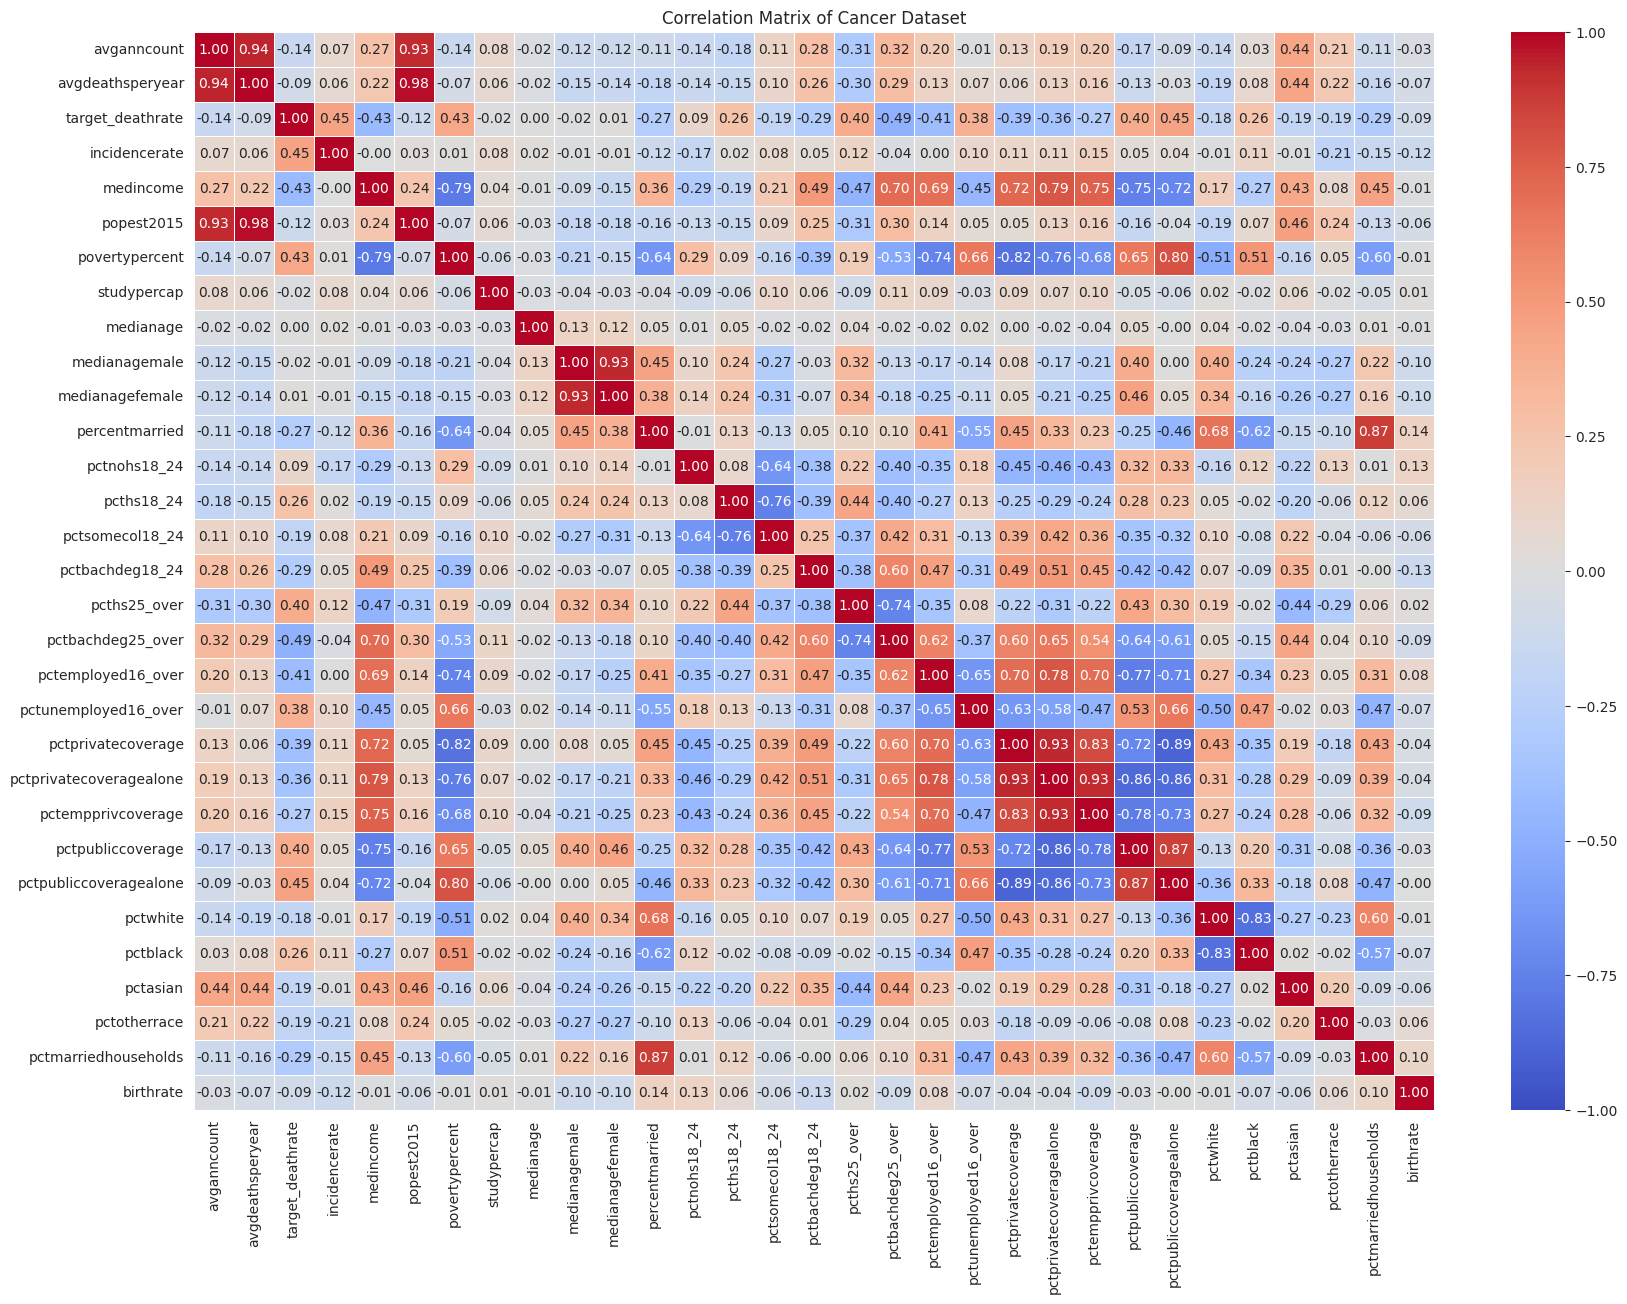

In [4]:
# Plot Correlation Matrix
plt.figure(figsize=(20, 14))

corr_matrix = data.drop( columns = ['binnedinc', 'geography']).corr(method = "pearson")

sns.heatmap(
    # corr_matrix[corr_matrix['target_deathrate'].abs() >= 0.4],
    corr_matrix,
    annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, linecolor='white', 
            # Reduce label size

            )
plt.title('Correlation Matrix of Cancer Dataset')
plt.show()

In [5]:
print("List of features with correlation >= 0.4 or <= -0.4 with target_deathrate: \n")
print(corr_matrix[corr_matrix['target_deathrate'].abs() >= 0.4]['target_deathrate'])

List of features with correlation >= 0.4 or <= -0.4 with target_deathrate: 

target_deathrate          1.000000
incidencerate             0.449432
medincome                -0.428615
povertypercent            0.429389
pcths25_over              0.404589
pctbachdeg25_over        -0.485477
pctemployed16_over       -0.412046
pctpubliccoverage         0.404572
pctpubliccoveragealone    0.449358
Name: target_deathrate, dtype: float64


In [6]:
corr_matrix[corr_matrix['target_deathrate'].abs() >= 0.4]['target_deathrate']

target_deathrate          1.000000
incidencerate             0.449432
medincome                -0.428615
povertypercent            0.429389
pcths25_over              0.404589
pctbachdeg25_over        -0.485477
pctemployed16_over       -0.412046
pctpubliccoverage         0.404572
pctpubliccoveragealone    0.449358
Name: target_deathrate, dtype: float64

Bien, podemos decir que existen ciertas correlaciones fuertes, y aun mas cuando se tratan de datos epidemiologicos o sociales. En este caso, existen correlaciones consideradas fuertes pero alrededor de variables cercanas al `target_Deathrate` como lo es `avgdeathsperyear` o `incidencerate`, los cuales descartamos en este análisis.

Las variabels que pueden aportar correlacion a la variable objetivo son:
- `medincome` (-0.43): Un ingreso mediano más alto se asocia con una tasa de mortalidad por cáncer más baja, lo que sugiere que la riqueza puede ser un factor protector.
- `povertypercent` (0.43) : Un mayor porcentaje de pobreza se asocia con una tasa de mortalidad por cáncer más alta, lo que indica que la pobreza puede ser un factor de riesgo.
- `pcths25_over` (0.40) : Un mayor porcentaje de personas con al menos educación secundaria se asocia con una tasa de mortalidad por cáncer más alta. De hecho podemos encontrar. Podemos encontrar una correlacion a su vez con `medincome` alta.
- `pctbachdeg25_over` (-0.49): Un mayor porcentaje de personas con título universitario se asocia con una tasa de mortalidad por cáncer más baja. A su vez, podemos encontrar una correlacion alta con `medincome` alta.
- `pctemployed16_over` (-0.41): Un mayor porcentaje de personas empleadas se asocia con una tasa de mortalidad por cáncer más baja.
- `pctpubliccoverage` (0.40): Un mayor porcentaje de personas con cobertura pública se asocia con una tasa de mortalidad por cáncer más alta, lo que podría indicar que la cobertura pública está más presente en áreas con mayores necesidades de salud.
- `pctpubliccoveragealone` (0.44): Un mayor porcentaje de personas con cobertura pública exclusiva se asocia con una tasa de mortalidad por cáncer más alta, lo que refuerza la idea de que la cobertura pública puede estar relacionada con áreas de mayor vulnerabilidad.

### 3. Dentro del modelo de regresión lineal, ¿Qué variables son las que más impacto tienen sobre el modelo?, ¿Cómo de significativas son con respecto al modelo?

Primero es importante realizar una seleccion de variables que influyan sobre la variable objetivo, pero esta selección debe de garantizar un nivel de independencia entre estas variables predictoras. Para esto, hagamosuna selccion de variables.

1. **TARGET**

`target_deathrate` (Variable Objetivo): Tasa de mortalidad por cáncer por cada 100.000 habitantes. Es el "indicador estrella" que queremos explicar o predecir.

1. **Factores Socioeconómicos**

`medincome`: Ingreso mediano por hogar. Es la "cartera" promedio de la zona.

`povertypercent`: Porcentaje de la población viviendo bajo el umbral de pobreza.

`studypercap`: Número de estudios clínicos per cápita realizados en la zona.

1. **Demografía**

`popest2015`: Estimación de la población total en el año 2015.

`geography`: Nombre del condado y el estado.

`medianage` / `medianagemale` / `medianagefemale`: Edad mediana total, de hombres y de mujeres.

`birthrate`: Tasa de natalidad.

`percentmarried` / `pctmarriedhouseholds`: Porcentaje de personas casadas y hogares compuestos por parejas casadas.

1. **Educación y Empleo**

`pctnohs18_24` / `pcths18_24` / `pctsomecol18_24` / `pctbachdeg18_24`: Nivel educativo alcanzado por jóvenes de 18 a 24 años (Sin secundaria, secundaria, algo de universidad o título universitario).

`pcths25_over` / `pctbachdeg25_over`: Nivel de estudios (Secundaria o Grado) para mayores de 25 años.

`pctemployed16_over`: Porcentaje de la población mayor de 16 años con o sin empleo.

1. **Cobertura Sanitaria y Etnias**

`pctprivatecoverage`: Porcentaje con seguro médico privado (total y exclusivo).

`pctpubliccoveragealone`: Porcentaje con cobertura pública (como Medicaid o Medicare). Piensa en esto como la "red de seguridad" estatal.

`pctwhite` / `pctblack` / `pctasian` / `pctotherrace`: Composición étnica de la población.

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df):
    X = add_constant(df)
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

cols = ['medincome', 'pctprivatecoverage', 'pctpubliccoveragealone', 'pctwhite', 'percentmarried']

vif_result = calculate_vif(data.drop( columns = ['binnedinc', 'geography', 'pctsomecol18_24', 'pctprivatecoveragealone', 'pctsomecol18_24', 'pctemployed16_over']))
print(vif_result)

                   feature          VIF
0                    const  1365.832083
1              avganncount     9.781422
2         avgdeathsperyear    31.574927
3         target_deathrate     2.077763
4            incidencerate     1.561832
5                medincome     7.607314
6               popest2015    26.485582
7           povertypercent     7.939854
8              studypercap     1.045350
9                medianage     1.023924
10           medianagemale     9.664786
11         medianagefemale    10.469080
12          percentmarried     8.288971
13            pctnohs18_24     1.673640
14              pcths18_24     1.628593
15         pctbachdeg18_24     1.960180
16            pcths25_over     3.775800
17       pctbachdeg25_over     5.717067
18    pctunemployed16_over     2.502541
19      pctprivatecoverage    15.847052
20      pctempprivcoverage     7.720959
21       pctpubliccoverage    23.608930
22  pctpubliccoveragealone    22.879244
23                pctwhite     7.100114


In [8]:
corr_matrix

,avganncount,avgdeathsperyear,target_deathrate,incidencerate,medincome,popest2015,povertypercent,studypercap,medianage,medianagemale,medianagefemale,percentmarried,pctnohs18_24,pcths18_24,pctsomecol18_24,pctbachdeg18_24,pcths25_over,pctbachdeg25_over,pctemployed16_over,pctunemployed16_over,pctprivatecoverage,pctprivatecoveragealone,pctempprivcoverage,pctpubliccoverage,pctpubliccoveragealone,pctwhite,pctblack,pctasian,pctotherrace,pctmarriedhouseholds,birthrate
avganncount,1.000000,0.939408,-0.143532,0.073553,0.269145,0.926894,-0.135694,0.082071,-0.024098,-0.124969,-0.122844,-0.106108,-0.143327,-0.182054,0.109455,0.284176,-0.311375,0.321021,0.199459,-0.009016,0.132244,0.186045,0.202349,-0.173548,-0.093699,-0.136501,0.031376,0.435071,0.209184,-0.106221,-0.034508
avgdeathsperyear,0.939408,1.000000,-0.090715,0.062690,0.223207,0.977634,-0.066918,0.063488,-0.024599,-0.148487,-0.144069,-0.181029,-0.136794,-0.151418,0.098464,0.259761,-0.295929,0.293210,0.125928,0.069701,0.056183,0.125820,0.160124,-0.131687,-0.027338,-0.187159,0.084607,0.443074,0.215149,-0.160266,-0.074420
target_deathrate,-0.143532,-0.090715,1.000000,0.449432,-0.428615,-0.120073,0.429389,-0.022285,0.004375,-0.021929,0.012048,-0.266820,0.088463,0.261976,-0.188688,-0.287817,0.404589,-0.485477,-0.412046,0.378412,-0.386066,-0.363704,-0.267399,0.404572,0.449358,-0.177400,0.257024,-0.186331,-0.189894,-0.293325,-0.087407
incidencerate,0.073553,0.062690,0.449432,1.000000,-0.001036,0.026912,0.009046,0.077283,0.018089,-0.014733,-0.009106,-0.119524,-0.170762,0.022644,0.077666,0.046835,0.121725,-0.038177,0.004906,0.099979,0.105174,0.109278,0.149825,0.046109,0.040812,-0.014510,0.113489,-0.008123,-0.208748,-0.152176,-0.118181
medincome,0.269145,0.223207,-0.428615,-0.001036,1.000000,0.235523,-0.788965,0.044003,-0.013288,-0.091663,-0.153278,0.355123,-0.289383,-0.190006,0.212953,0.492810,-0.471348,0.704928,0.693432,-0.453108,0.724175,0.788048,0.747294,-0.754822,-0.719756,0.167225,-0.270232,0.425844,0.083635,0.446083,-0.010195
popest2015,0.926894,0.977634,-0.120073,0.026912,0.235523,1.000000,-0.065299,0.055722,-0.025219,-0.176608,-0.177932,-0.160463,-0.126582,-0.151821,0.093202,0.248375,-0.311849,0.297463,0.140146,0.050768,0.052677,0.132660,0.158650,-0.160066,-0.041469,-0.190095,0.073044,0.464168,0.241468,-0.127979,-0.057740
povertypercent,-0.135694,-0.066918,0.429389,0.009046,-0.788965,-0.065299,1.000000,-0.055652,-0.029280,-0.214001,-0.148164,-0.642857,0.288106,0.094211,-0.162099,-0.387122,0.194361,-0.531600,-0.736767,0.655148,-0.822534,-0.761672,-0.683100,0.651162,0.798642,-0.509433,0.511530,-0.157289,0.047096,-0.604953,-0.012283
studypercap,0.082071,0.063488,-0.022285,0.077283,0.044003,0.055722,-0.055652,1.000000,-0.026030,-0.036647,-0.030577,-0.038143,-0.090387,-0.057035,0.101220,0.063819,-0.085128,0.108594,0.088021,-0.031957,0.092545,0.072381,0.100063,-0.051497,-0.055512,0.023291,-0.019761,0.062543,-0.015247,-0.051736,0.010676
medianage,-0.024098,-0.024599,0.004375,0.018089,-0.013288,-0.025219,-0.029280,-0.026030,1.000000,0.129119,0.124678,0.046372,0.006178,0.050574,-0.018325,-0.016909,0.036587,-0.020352,-0.024650,0.018590,0.004665,-0.024272,-0.036926,0.049060,-0.003298,0.035009,-0.017173,-0.038424,-0.030277,0.014504,-0.008276
medianagemale,-0.124969,-0.148487,-0.021929,-0.014733,-0.091663,-0.176608,-0.214001,-0.036647,0.129119,1.000000,0.933696,0.449986,0.100486,0.241310,-0.274801,-0.034135,0.318277,-0.131599,-0.165199,-0.142737,0.082232,-0.167064,-0.208664,0.398967,0.002479,0.398044,-0.242748,-0.238322,-0.266655,0.222278,-0.104105


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   object 
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  geography                3047 non-null   object 
 13  percentmarried           3047 non-null   float64
 14  pctnohs18_24            